## Prognozowanie ceny akcji
W tym notatniku przedstawiono proces uczenia maszynowego wykorzystanego w celu przewidywania cen akcji.
1. Import danych
2. Analiza danych
3. Czyszczenie danych
4. Inżynieria cech
5. Szkolenie modelu
6. Ocena modelu

### Import bibliotek

In [45]:
#import libraries
import numpy as np
import pandas as pd
from sklearn import metrics
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import Dropout
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams["figure.figsize"] = (14, 7)
mpl.rcParams["figure.facecolor"] = "white"
mpl.rcParams["axes.facecolor"] = "white"

### Nieprzewidywalność i wpływ zdarzeń na kurs - przykład notowań WIG20 w czasie pandemii

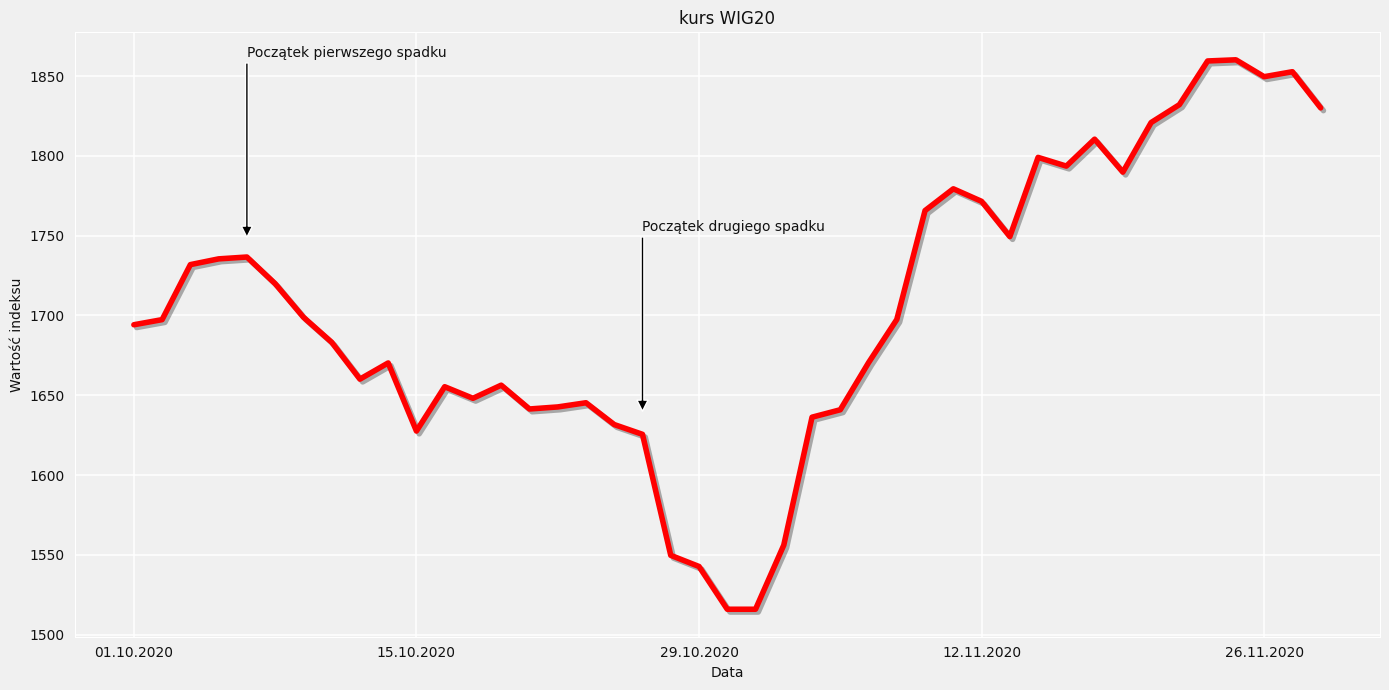

In [52]:
import matplotlib.patheffects as path_effects

wig_dates = [
    "01.10.2020",
    "02.10.2020",
    "05.10.2020",
    "06.10.2020",
    "07.10.2020",
    "08.10.2020",
    "09.10.2020",
    "12.10.2020",
    "13.10.2020",
    "14.10.2020",
    "15.10.2020",
    "16.10.2020",
    "19.10.2020",
    "20.10.2020",
    "21.10.2020",
    "22.10.2020",
    "23.10.2020",
    "26.10.2020",
    "27.10.2020",
    "28.10.2020",
    "29.10.2020",
    "30.10.2020",
    "01.11.2020",
    "02.11.2020",
    "03.11.2020",
    "04.11.2020",
    "05.11.2020",
    "06.11.2020",
    "09.11.2020",
    "10.11.2020",
    "12.11.2020",
    "13.11.2020",
    "16.11.2020",
    "17.11.2020",
    "18.11.2020",
    "19.11.2020",
    "20.11.2020",
    "23.11.2020",
    "24.11.2020",
    "25.11.2020",
    "26.11.2020",
    "27.11.2020",
    "30.11.2020",
]

ratios = [
    1694.18,
    1697.39,
    1731.85,
    1735.45,
    1736.61,
    1719.91,
    1698.91,
    1683.21,
    1660.12,
    1670.26,
    1627.59,
    1655.36,
    1648.11,
    1656.34,
    1641.42,
    1642.7,
    1645.32,
    1631.66,
    1625.54,
    1549.74,
    1542.76,
    1515.97,
    1515.97,
    1556.14,
    1636.28,
    1640.94,
    1670.43,
    1697.49,
    1765.71,
    1779.34,
    1771.49,
    1749.41,
    1799.02,
    1793.56,
    1810.43,
    1789.79,
    1820.85,
    1832.04,
    1859.42,
    1860.15,
    1849.57,
    1852.69,
    1830.04,
]

wig_ratio = {'WIG20': ratios}

data = pd.DataFrame(wig_ratio, index=wig_dates)

fig, ax = plt.subplots(figsize=(14, 7))
ax.set_facecolor("#f0f0f0")
fig.patch.set_facecolor("#f0f0f0")

ax.grid(True, color="white", linewidth=1.2, alpha=0.9)
ax.tick_params(colors="#111111")
ax.xaxis.label.set_color("#111111")
ax.yaxis.label.set_color("#111111")
ax.title.set_color("#111111")

spx = data['WIG20']
spx.plot(ax=ax, style='r-', path_effects=[path_effects.SimpleLineShadow(), path_effects.Normal()], linewidth=4)

# 07.10.2020 - decyzja o żółtej strefie w całym kraju + maseczki także na zewnątrz (od 10.10)
# 27.10.2020 - cały kraj w czerwonej strefie + duże zmiany w szkołach (nauczanie zdalne)

ax.set_title('kurs WIG20')
ax.annotate(
    'Początek pierwszego spadku',
    color="#111111",
    xy=(4, 1719 + 30),
    xytext=(4, 1719 + 150),
    arrowprops=dict(facecolor='black', headwidth=8, width=2, headlength=8),
    horizontalalignment='left',
    verticalalignment='top'
)

ax.annotate(
    'Początek drugiego spadku',
     color="#111111",
    xy=(18, 1610 + 30),
    xytext=(18, 1610 + 150),
    arrowprops=dict(facecolor='black', headwidth=8, width=2, headlength=8),
    horizontalalignment='left',
    verticalalignment='top'
)

ax.set_xlabel('Data')
ax.set_ylabel('Wartość indeksu')

plt.tight_layout()
plt.show()



### Import danych

In [32]:
dataset = pd.read_csv("../data/google.csv")

### Analiza zbioru danych

In [33]:
dataset.describe()

,High,Low,Open,Close,Volume,Adj Close
count,4317.000000,4317.000000,4317.000000,4317.000000,4.317000e+03,4317.000000
mean,639.682936,627.615621,633.603748,633.852357,6.523837e+06,633.852357
std,561.783142,552.069438,556.527532,557.255541,7.830526e+06,557.255541
min,50.680038,47.800831,49.409801,49.818268,7.922000e+03,49.818268
25%,247.507278,241.469910,244.832306,244.334183,1.593563e+06,244.334183
50%,401.988251,395.168823,399.004425,398.561096,3.851583e+06,398.561096
75%,933.440002,923.030029,929.059998,928.799988,8.268878e+06,928.799988
max,2936.409912,2912.290039,2918.989990,2916.840088,8.254163e+07,2916.840088


In [34]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4317 entries, 0 to 4316
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       4317 non-null   object 
 1   High       4317 non-null   float64
 2   Low        4317 non-null   float64
 3   Open       4317 non-null   float64
 4   Close      4317 non-null   float64
 5   Volume     4317 non-null   float64
 6   Adj Close  4317 non-null   float64
dtypes: float64(6), object(1)
memory usage: 236.2+ KB


In [35]:
dataset.head()

,Date,High,Low,Open,Close,Volume,Adj Close
0,2004-08-19,51.835709,47.800831,49.813290,49.982655,44871361.0,49.982655
1,2004-08-20,54.336334,50.062355,50.316402,53.952770,22942874.0,53.952770
2,2004-08-23,56.528118,54.321388,55.168217,54.495735,18342897.0,54.495735
3,2004-08-24,55.591629,51.591621,55.412300,52.239197,15319808.0,52.239197
4,2004-08-25,53.798351,51.746044,52.284027,52.802086,9232276.0,52.802086


## Inżynieria parametrów

In [36]:
#normalizacja warości do przedziału 0-1
trainset = dataset.iloc[:, 3:4].values
scaler = MinMaxScaler(feature_range = (0,1))
data_scaled = scaler.fit_transform(trainset)
data_scaled

array([[1.40608776e-04],
       [3.15935047e-04],
       [2.00670999e-03],
       ...,
       [9.50609507e-01],
       [9.57878900e-01],
       [9.57140076e-01]])

### Podział zbioru na dane treningowe i dane testowe

In [37]:
x_train = []
y_train = []
window = 70 #szerokość okna

for i in range(window, 3500):
    x_train.append(data_scaled[i-window:i, 0])
    y_train.append(data_scaled[i,0])
    
x_train, y_train = np.array(x_train), np.array(y_train)

x_test = []
y_test = []
for i in range(3501, 4300):
    x_test.append(data_scaled[i-window:i, 0])
    y_test.append(data_scaled[i,0])
    
x_test, y_test = np.array(x_test), np.array(y_test)

In [38]:
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1],1))
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1],1))

### Utworzenie modelu LSTM

In [39]:
#zbuduj model sztucznej sieci neuronowej LSTM (long short-term memory)
regressor = Sequential()
regressor.add(LSTM(units = 50,return_sequences = True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units = 50,return_sequences = True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units = 50,return_sequences = True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units = 50))
regressor.add(Dropout(0.2))
regressor.add(Dense(units = 1))
regressor.compile(optimizer = 'adam',loss = 'mean_squared_error')

### Trenowanie modelu

In [40]:
regressor.fit(x_train, y_train,epochs = 10, batch_size = 32)

### Przewidywanie wartości dla danych testowych

In [41]:
predicted_price = regressor.predict(x_test)
predicted_price = scaler.inverse_transform(predicted_price)
predicted_price

array([[1134.0602],
       [1135.241 ],
       [1137.2379],
       [1139.9882],
       [1143.3599],
       [1147.1614],
       [1151.4823],
       [1156.3801],
       [1161.8875],
       [1168.0459],
       [1174.6865],
       [1181.5193],
       [1188.2643],
       [1194.6053],
       [1200.3575],
       [1205.4136],
       [1209.7731],
       [1213.5022],
       [1216.725 ],
       [1219.5463],
       [1222.0249],
       [1224.188 ],
       [1226.0278],
       [1227.5154],
       [1228.5472],
       [1229.0385],
       [1228.9614],
       [1228.311 ],
       [1227.1451],
       [1225.5642],
       [1223.7554],
       [1221.964 ],
       [1220.3992],
       [1219.2311],
       [1218.5334],
       [1218.1992],
       [1218.0222],
       [1217.7688],
       [1217.1493],
       [1215.9806],
       [1214.149 ],
       [1211.6672],
       [1208.6229],
       [1205.1793],
       [1201.4922],
       [1197.6576],
       [1193.7766],
       [1190.0007],
       [1186.522 ],
       [1183.3833],


In [42]:
# rzeczywisty kurs dla porównania
real_price =  scaler.inverse_transform(y_test.reshape(-1, 1))
real_price

array([[1172.2199707 ],
       [1196.56005859],
       [1191.        ],
       [1186.95996094],
       [1181.01000977],
       [1262.58996582],
       [1239.13000488],
       [1251.        ],
       [1271.        ],
       [1228.01000977],
       [1220.01000977],
       [1228.        ],
       [1205.90002441],
       [1229.61999512],
       [1225.        ],
       [1237.        ],
       [1240.4699707 ],
       [1249.90002441],
       [1243.        ],
       [1236.97998047],
       [1235.18994141],
       [1229.26000977],
       [1224.72998047],
       [1202.0300293 ],
       [1205.02001953],
       [1208.        ],
       [1200.        ],
       [1207.14001465],
       [1208.81994629],
       [1227.59997559],
       [1241.29003906],
       [1237.44995117],
       [1244.22998047],
       [1234.97998047],
       [1204.27001953],
       [1193.80004883],
       [1186.30004883],
       [1158.67004395],
       [1172.18994141],
       [1161.63000488],
       [1172.7199707 ],
       [1170.739

### Porównanie danych rzeczywistych i prognozy

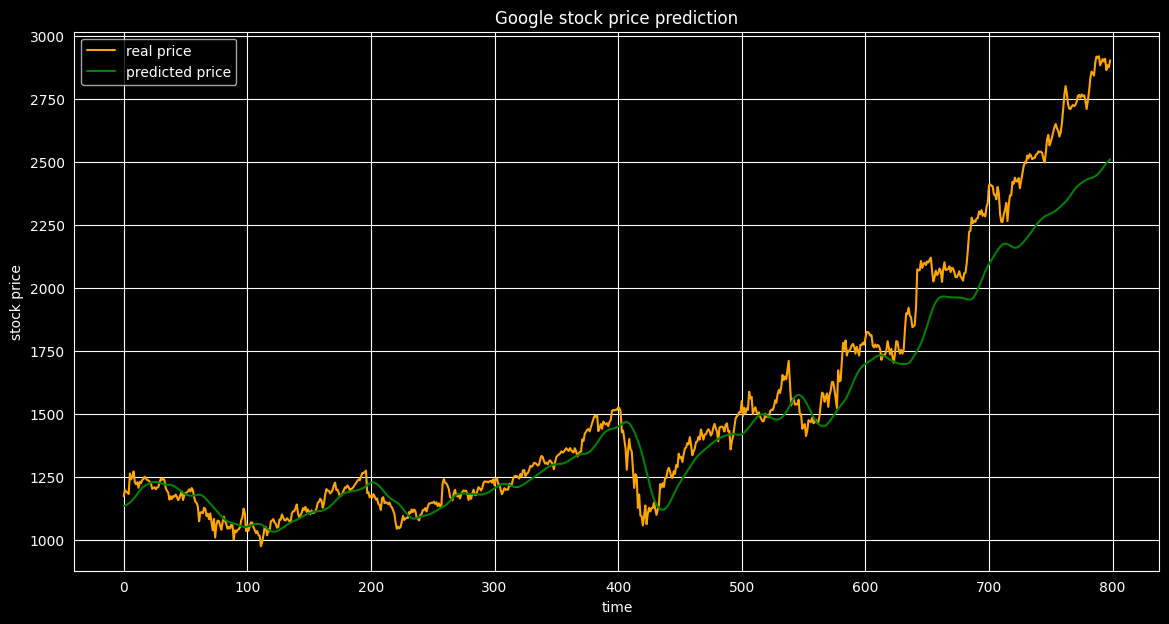

In [43]:
plt.plot(real_price, color = 'orange', label = 'real price')
plt.plot(predicted_price, color = 'green', label = 'predicted price')
plt.title('Google stock price prediction')
plt.xlabel('time')
plt.ylabel('stock price')
plt.legend()
plt.show()

### Ewaluacja

In [44]:
# metryki ewaluacji
print(f'RMSE {metrics.mean_squared_error(predicted_price, real_price)}')
print(f'MAE {metrics.mean_absolute_error(predicted_price, real_price)}')

RMSE 19776.05208858851
MAE 94.98071770315923
